In [3]:
#This project is about the "steel industry electricity consumption data"
#project motive is to predicting the electricity usage in diffrent cases
#Part(A): EDA
#1.Preprocessing steps
#2.Identifying missing values
#3.Summary statistics
#4.Visualisation of relation of various factor on regarding the usage
#5.Correlation analysis
#6.Finding outliers and its visualisations

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
 datas=pd.read_csv('Steel_industry_data.csv')

In [6]:
datas

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


In [8]:
datas.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [10]:
datas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [11]:
datas.shape

(35040, 11)

In [13]:

datas= pd.read_csv("Steel_industry_data.csv")

# Step 1
datas['date'] = pd.to_datetime(datas['date'], format='%d/%m/%Y %H:%M', errors='coerce')

#  Step 2: Check and handle missing values
# Display missing values per column
missing_counts = datas.isnull().sum()
print("Missing values:\n", missing_counts)

# Optionally drop rows with missing critical values (e.g., date, Usage_kWh)
datas.dropna(subset=['date', 'Usage_kWh'], inplace=True)

#  Step 3: Remove duplicates
datas.drop_duplicates(inplace=True)

#  Step 4: Fix column names (strip whitespace and replace periods)
datas.columns = datas.columns.str.strip().str.replace('.', '_').str.replace('(', '').str.replace(')', '')

# Step 5: Convert data types (if needed)
numeric_columns = ['Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
                   'Leading_Current_Reactive_Power_kVarh', 'CO2_(tCO2)',
                   'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']


# Step 6: Fill or handle remaining missing values
# Here, we can choose to fill NA with 0 or use other imputation strategies
datas.fillna(0, inplace=True)

#  Final check
print("\nCleaned Data Overview:")
print(datas.info())


Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Cleaned Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64       
 3   

In [14]:
datas.describe()

,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2tCO2,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,2018-07-02 11:52:30,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-04-02 05:56:15,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,2018-07-02 11:52:30,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,2018-10-01 17:48:45,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,2018-12-31 23:45:00,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000
std,NaN,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317


<Axes: xlabel='Load_Type', ylabel='Usage_kWh'>

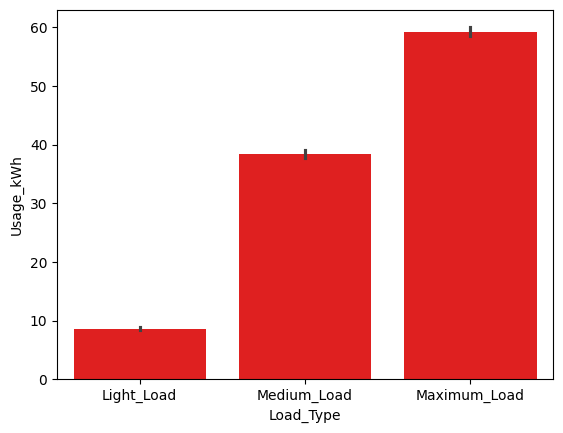

In [15]:
#Bar plot for analysing the kWh usage in difference loads
sns.barplot(data=datas,x="Load_Type",y="Usage_kWh",color="r")

<Axes: xlabel='WeekStatus', ylabel='Usage_kWh'>

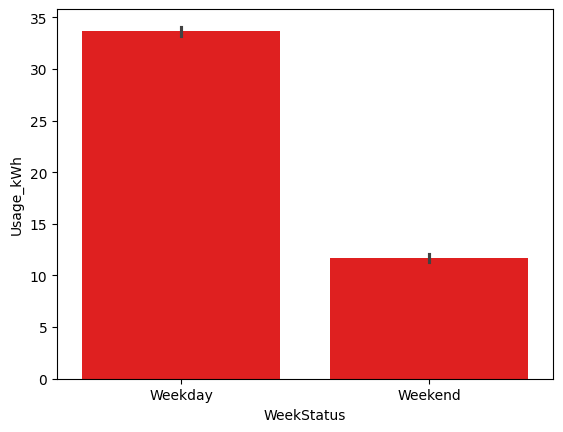

In [16]:
#Bar plot for analysing the kWh usage in different weeks
sns.barplot(data=datas,x="WeekStatus",y="Usage_kWh",color="r")

<Axes: xlabel='Day_of_week', ylabel='Usage_kWh'>

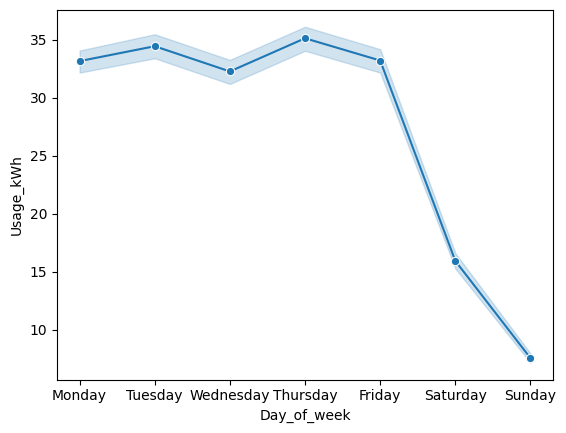

In [17]:
#KWH Usage analysis over days
sns.lineplot(data=datas,x="Day_of_week",y="Usage_kWh",marker="o")

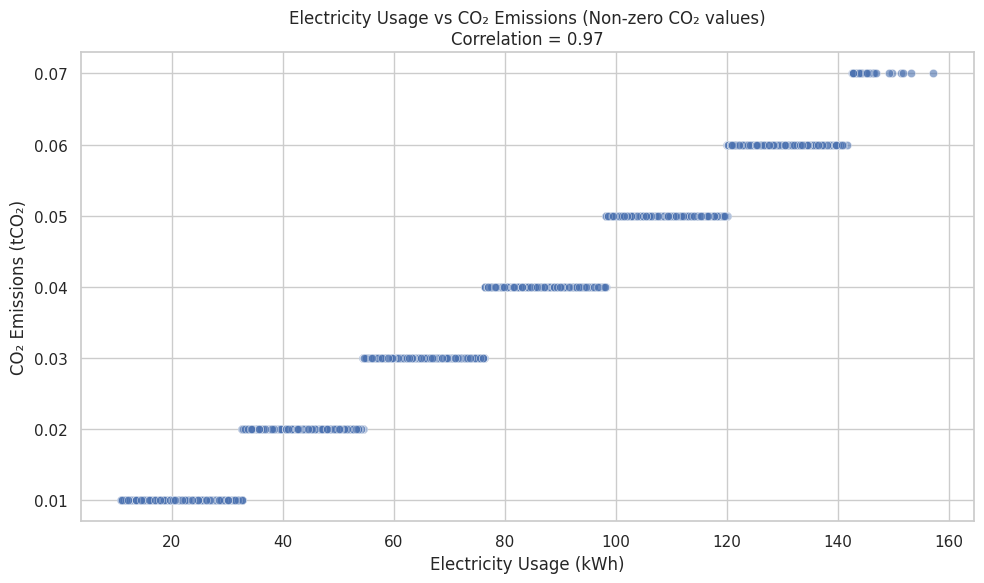

In [18]:
#Scatter plot for showing the relation between Electricity usage and CO2 emission
datas = pd.read_csv("Steel_industry_data.csv")

# Filter out rows where CO2 emissions are zero
df_nonzero_co2 = datas[datas["CO2(tCO2)"] > 0]

# Calculate correlation between electricity usage and CO2 emissions
correlation = df_nonzero_co2["Usage_kWh"].corr(df_nonzero_co2["CO2(tCO2)"])

# Set plot style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nonzero_co2, x="Usage_kWh", y="CO2(tCO2)", alpha=0.6)
plt.title(f"Electricity Usage vs CO₂ Emissions (Non-zero CO₂ values)\nCorrelation = {correlation:.2f}")
plt.xlabel("Electricity Usage (kWh)")
plt.ylabel("CO₂ Emissions (tCO₂)")
plt.tight_layout()
plt.show()


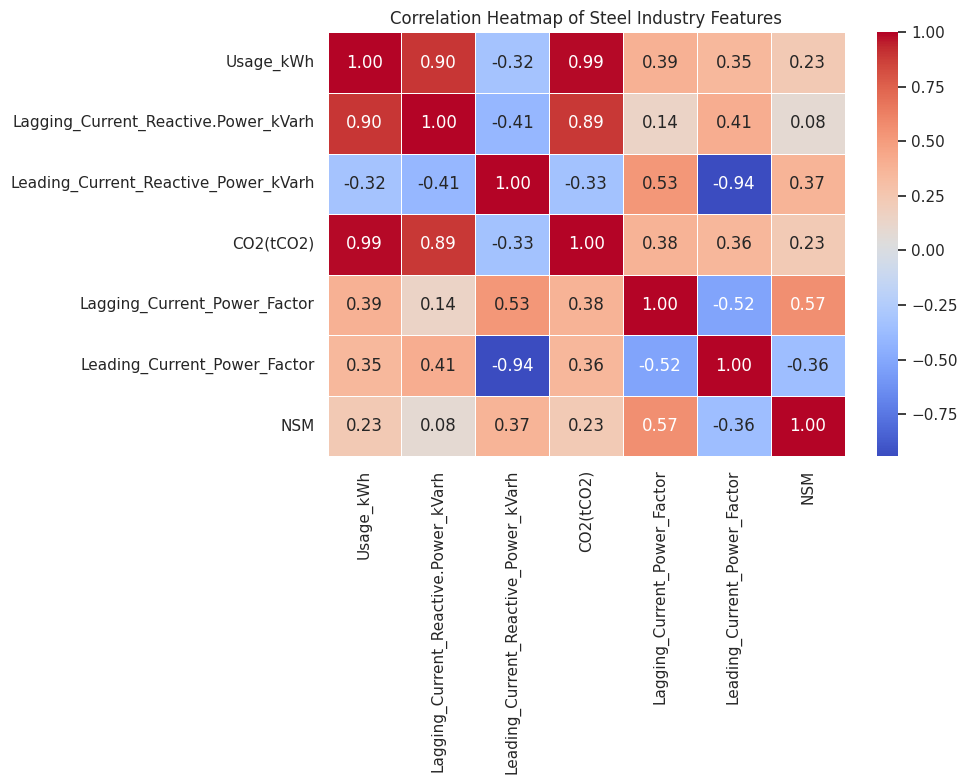

In [19]:
#correlation heatmap for the numerical columns
# Compute the correlation matrix for numerical features
correlation_matrix = datas.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
sns.set(style="white")

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Set plot title
plt.title("Correlation Heatmap of Steel Industry Features")
plt.tight_layout()

# Show the plot
plt.show()


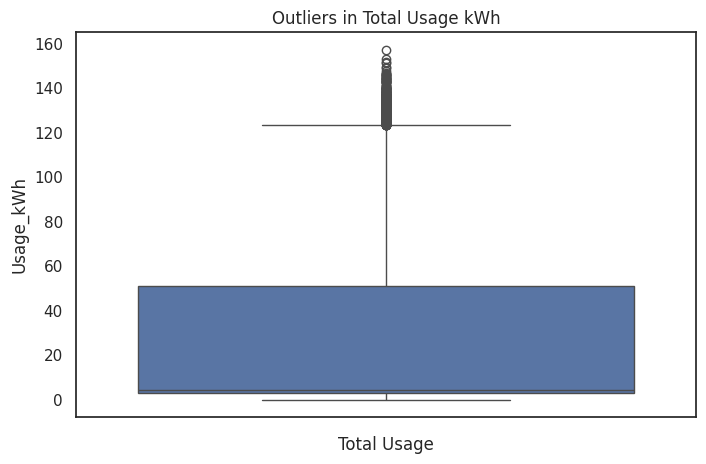

In [20]:
#Detecting Outliers
plt.figure(figsize=(8,5))
sns.boxplot(datas['Usage_kWh'])
plt.title('Outliers in Total Usage kWh')
plt.xlabel('Total Usage')
plt.show()

In [21]:
#IQR Method for outlier detection
Q1=datas['Usage_kWh'].quantile(0.25)
Q3=datas['Usage_kWh'].quantile(0.75)

IQR= Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=datas[(datas['Usage_kWh']<lower_bound) | (datas['Usage_kWh'] > upper_bound)]
print(f'number of outliers detected: {len(outliers)}')
print(outliers[['date','Usage_kWh']])

number of outliers detected: 328
                   date  Usage_kWh
140    02/01/2018 11:15     128.52
141    02/01/2018 11:30     144.47
143    02/01/2018 12:00     123.30
150    02/01/2018 13:45     124.45
153    02/01/2018 14:30     129.10
...                 ...        ...
33851  19/12/2018 15:00     145.22
33853  19/12/2018 15:30     130.46
33855  19/12/2018 16:00     125.21
33856  19/12/2018 16:15     133.56
33859  19/12/2018 17:00     125.50

[328 rows x 2 columns]


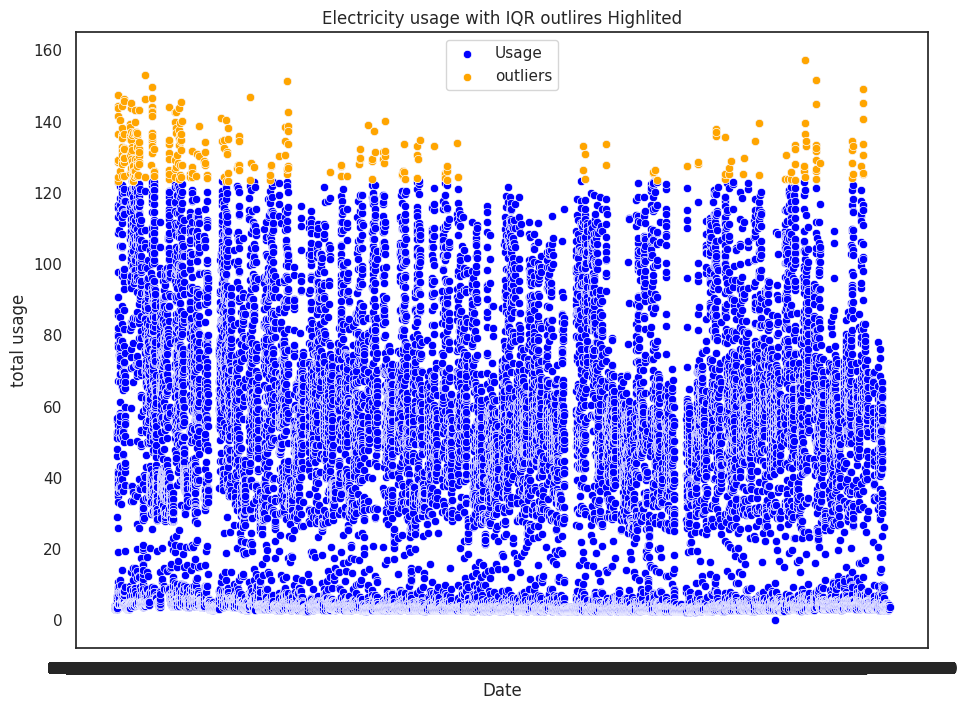

In [23]:
#Visaulisation of IQR outliers
plt.figure(figsize=(11,8))
sns.scatterplot(data=datas,x='date',y='Usage_kWh',label='Usage',color='blue')
sns.scatterplot(data=outliers,x='date',y='Usage_kWh',label='outliers',color='orange')
plt.title('Electricity usage with IQR outlires Highlited')
plt.xlabel('Date')
plt.ylabel('total usage')
plt.show()